<img src="https://github.com/nicholasmetherall/digital-earth-pacific-macblue-activities/blob/main/attachments/images/DE_Pacific_banner.JPG?raw=true" width="900"/>

Figure 1.1.a. Jupyter environment + Python notebooks

# Digital Earth Pacific Notebook 1 prepare postcard and load data to csv

The objective of this notebook is to prepare a geomad postcard for your AOI (masking, scaling and loading additional band ratios and spectral indices) and sampling all the datasets into a csv based on your training data geodataframe.

## Step 1.1: Configure the environment

In [1]:
from datetime import datetime
from shapely.geometry import Polygon
from shapely import box
from pyproj import CRS 
import folium
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio as rio
import xarray as xr
import rioxarray
import joblib
from ipyleaflet import basemaps
import pystac_client
from dask.distributed import Client as DaskClient
from odc.stac import load, configure_s3_access
import planetary_computer
from odc.stac import load
from pystac.client import Client
from skimage.feature import graycomatrix, graycoprops
import matplotlib.pyplot as plt
from matplotlib import colors
from utils import load_data, load_s1_dem, scale, calculate_band_indices, apply_mask, mask_water, all_masks, do_prediction

In [2]:
# Reload scripts and imports
%load_ext autoreload
%autoreload 2

In [3]:
# Predefined variable for title and version

# Enter your initials
initials = "mw"

# Enter your site name
site = "samoa"

# Date
date = datetime.now()

# Make a clean version string
version = f"{initials}-{site}-{date.strftime('%d%m%Y')}"
print(version)

mw-samoa-02032026


## Step 1.2: Configure STAC access and search parameters

In [4]:
catalog = "https://stac.digitalearthpacific.org"
client = Client.open(catalog)

In [7]:
## Use training data bounds

# training = gpd.read_file(f"training-data/nm-{site}.geojson")
trainings = gpd.read_file("training-data/mw-samoa-27022026_postcard_4.geojson")
trainings = trainings.to_crs("EPSG:4326")

#aoi = gpd.read_file("training-data/apia_aoi.geojson")
#aoi = aoi.to_crs("EPSG:4326")

training = trainings#aoi#.clip(trainings)

min_lon, min_lat, max_lon, max_lat = training.total_bounds

bbox = [min_lon, min_lat, max_lon, max_lat]

In [8]:
training

,lulc_class,value_id,lulc_code,geometry
0,Settlements,5,5,POINT (-171.80608 -13.82372)
1,Settlements,5,5,POINT (-171.8146 -13.82825)
2,Settlements,5,5,POINT (-171.81379 -13.82703)
3,Settlements,5,5,POINT (-171.8214 -13.82675)
4,Settlements,5,5,POINT (-171.80683 -13.8275)
...,...,...,...,...
393,Grassland,3,3,POINT (-172.10402 -13.84666)
394,Grassland,3,3,POINT (-172.10385 -13.84695)
395,Grassland,3,3,POINT (-172.10818 -13.84091)
396,Grassland,3,3,POINT (-172.10788 -13.8411)


In [9]:
training.columns.unique()

Index(['lulc_class', 'value_id', 'lulc_code', 'geometry'], dtype='object')

In [10]:
# bbox = [178.410921, -18.188382, 178.46952, -18.14731]

In [11]:
datetime = "2023"

items = client.search(
    collections=["dep_s2_geomad"],
    datetime=datetime,
    bbox=bbox
).item_collection()

print(f"Found {len(items)} items in for {datetime}")

Found 4 items in for 2023


In [12]:
measurements = ["nir", "red", "blue", "green", "emad", "smad", "bcmad", "green", "nir08", "nir09", "swir16", "swir22", "coastal", "rededge1", "rededge2", "rededge3"]
data = load_data(
    items,
    measurements,
    bbox,
)
    
# Now you can use the 'data' variable
print(data)

<xarray.Dataset> Size: 4GB
Dimensions:      (y: 6745, x: 14955, time: 1)
Coordinates:
  * y            (y) float64 54kB -1.501e+06 -1.501e+06 ... -1.569e+06
  * x            (x) float64 120kB 4.142e+06 4.142e+06 ... 4.292e+06 4.292e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 8B 2023-01-01
Data variables: (12/15)
    nir          (time, y, x) uint16 202MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    red          (time, y, x) uint16 202MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    blue         (time, y, x) uint16 202MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    green        (time, y, x) uint16 202MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    emad         (time, y, x) float32 403MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    smad         (time, y, x) float32 403MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    ...           ...
    swir16       (time, y, x) uint16 202MB d

In [13]:
# dask_client = DaskClient(n_workers=1, threads_per_worker=16, memory_limit='16GB')
# configure_s3_access(cloud_defaults=True, requester_pays=True)

In [14]:
scaled = scale(data)
scaled = scaled.compute().squeeze()

In [15]:
scaled = calculate_band_indices(scaled)
# Dataset = scaled
# Dataset.odc.explore(vmin = 0, vmax = 0.3, bands = ["red", "green", "blue"], crs="EPSG:3832", name=site)

In [16]:
# All masks
masked_scaled, mask = all_masks(scaled, return_mask = True)
# masked_scaled.odc.explore(vmin=0, vmax=0.3, bands=["red", "green", "blue"], crs="EPSG:3832", name=site)

In [17]:
# masked_scaled.odc.explore(bands="red")

In [18]:
# combined_ds = masked_scaled.drop_vars("count")
combined_da = masked_scaled.to_dataarray()
combined_da = combined_da.squeeze()#.stack(dims=["y", "x"])#.transpose()
stacked_arrays_2d = combined_da.stack(new_dim=("y", "x")) 
reordered_data_array = stacked_arrays_2d.transpose('new_dim', 'variable')
stacked_arrays_2d.shape

(32, 100871475)

In [19]:
# Replace any infinities with NaN
stacked_arrays_2d = stacked_arrays_2d.where(stacked_arrays_2d != float("inf"))
stacked_arrays_2d = stacked_arrays_2d.where(stacked_arrays_2d != float("-inf"))

# Replace any NaN values with 0
df = stacked_arrays_2d.squeeze().fillna(0).transpose().to_pandas()

# Remove the all-zero rows
zero_mask = (df == 0).all(axis=1)  # Creates a boolean Series
non_zero_df = df.loc[~zero_mask]  # Filters out all-zero rows

# Create a new array to hold the predictions
full_pred = pd.Series(np.nan, index=df.index)

reordered_data_array = stacked_arrays_2d.transpose('new_dim', 'variable')

### Model training

In [20]:
reordered_data_array

<xarray.DataArray (new_dim: 100871475, variable: 32)> Size: 26GB
array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [ 0.4236    ,  0.0263    ,  0.0271    , ..., -0.64189435,
        -0.72125   , -0.09013449],
       [ 0.4303    ,  0.024     ,  0.024     , ..., -0.65230042,
        -0.7385    , -0.09289097],
       [ 0.4275    ,  0.0254    ,  0.0257    , ..., -0.64441219,
        -0.7289    , -0.09118556]])
Coordinates:
    spatial_ref  int32 4B 3832
    time         datetime64[ns] 8B 2023-01-01
  * variable     (variable) object 256B 'nir' 'red' ... 'awei' 'tc_wetness'
  * new_dim      (new_dim) object 807MB MultiIndex
  * y            (new_dim) float64 807MB -1.501e+06 -1.501e+06 ... -1.569e+06
  * x            (new_dim) float64 807MB 4.142e+06 4.142e+06 ... 4.292e+06

In [21]:
# # Reproject training data to the GeoMAD CRS and convert to xarray
# training_reprojected = training.to_crs(masked_scaled.odc.crs)
# training_da = training_reprojected.assign(
#     x=training_reprojected.geometry.x, y=training_reprojected.geometry.y
# ).to_xarray()

# # Extract training values from the masked dataset
# training_values = (
#     masked_scaled.sel(training_da[["x", "y"]], method="nearest")
#     .squeeze()
#     .compute()
#     .to_pandas()
# )
# training_values

In [22]:
model = joblib.load("models/mw-samoa-27022026-test.model")

In [23]:
# Predict the classes
predicted = model.predict(reordered_data_array)

In [24]:
# print("Prediction Input CRS:", reordered_data_array.rio.crs)
print("Prediction Input CRS:", data.rio.crs)

Prediction Input CRS: EPSG:3832


In [25]:
# Reshape back to the original 2D array
reordered_data_array = predicted.reshape(len(masked_scaled.y), len(masked_scaled.x))

# Convert to an xarray again, because it's easier to work with
predicted_da = xr.DataArray(
    reordered_data_array, coords={"y": masked_scaled.y, "x": masked_scaled.x}, dims=["y", "x"]
)

In [26]:
print(predicted_da.dtype)  # Check the dtype of your DataArray
predicted_da = predicted_da.astype('float32')  # Convert to float32

# Check for NaN values
if np.isnan(predicted_da).any():
    print("NaN values found in the data")
    # Handle NaN values, e.g. by filling them
    predicted_da = predicted_da.fillna(-9999)  # Replace NaN with 0 or appropriate value

object


In [27]:
masked_scaled = masked_scaled.compute()

In [28]:
# masked_scaled = masked_scaled.drop_vars("count")

predicted = do_prediction(masked_scaled, model)
predicted
# predicted.odc.explore(cmap=c_map, tiles=basemaps.Esri.WorldImagery)

<xarray.DataArray (y: 6745, x: 14955)> Size: 807MB
array([['4', '4', '4', ..., '4', '4', '4'],
       ['4', '4', '4', ..., '4', '4', '4'],
       ['4', '4', '4', ..., '4', '4', '4'],
       ...,
       ['4', '4', '4', ..., '1', '1', '1'],
       ['4', '4', '4', ..., '1', '1', '1'],
       ['4', '4', '4', ..., '1', '1', '1']], dtype=object)
Coordinates:
  * y        (y) float64 54kB -1.501e+06 -1.501e+06 ... -1.569e+06 -1.569e+06
  * x        (x) float64 120kB 4.142e+06 4.142e+06 ... 4.292e+06 4.292e+06

In [29]:
print(predicted)

<xarray.DataArray (y: 6745, x: 14955)> Size: 807MB
array([['4', '4', '4', ..., '4', '4', '4'],
       ['4', '4', '4', ..., '4', '4', '4'],
       ['4', '4', '4', ..., '4', '4', '4'],
       ...,
       ['4', '4', '4', ..., '1', '1', '1'],
       ['4', '4', '4', ..., '1', '1', '1'],
       ['4', '4', '4', ..., '1', '1', '1']], dtype=object)
Coordinates:
  * y        (y) float64 54kB -1.501e+06 -1.501e+06 ... -1.569e+06 -1.569e+06
  * x        (x) float64 120kB 4.142e+06 4.142e+06 ... 4.292e+06 4.292e+06


In [30]:
predicted = predicted.where(mask)
# `prediction` is your predicted class array# `mask` is your boolean mask, where True means masked
nodata_value = -9998  # or -9999, or whatever you chooseprediction_with_mask = prediction.copy()
predicted['mask'] = nodata_value

In [31]:
predicted_filled = predicted.fillna(-9999)
predicted_int = predicted_filled.astype(np.int32)

In [32]:
# predicted.odc.write_cog("prediction_serua_3b.tif")

In [33]:
from matplotlib import colors

# Updated classes list to include No Data (Code 0)
classes = [
    [0, 'No_Data', '#00000000'], # <-- NEW: Code 0 mapped to a light gray color
    [1, 'Forest', '#064a00'],
    [2, 'Cropland', '#FFEE8C' ],
    [3, 'Grassland','#78ee8c'],
    [4, 'Wetland', '#73ffd2'],
    [5, 'Settlements', '#bd0007'],
    [6, 'Land','#919191'],
]

# classes = [ 
#     [1, 'Forest_land', '#064a00'],
#     [2, 'Grazing_Cropland', '#b67e00' ],
#     [3, 'Wetland', '#73ffd2'],
#     [4, 'Settlements', '#bd0007'],
#     [5, 'Bare_land','#919191'],
#     [6, 'Water','#71a8ff'],
# ]


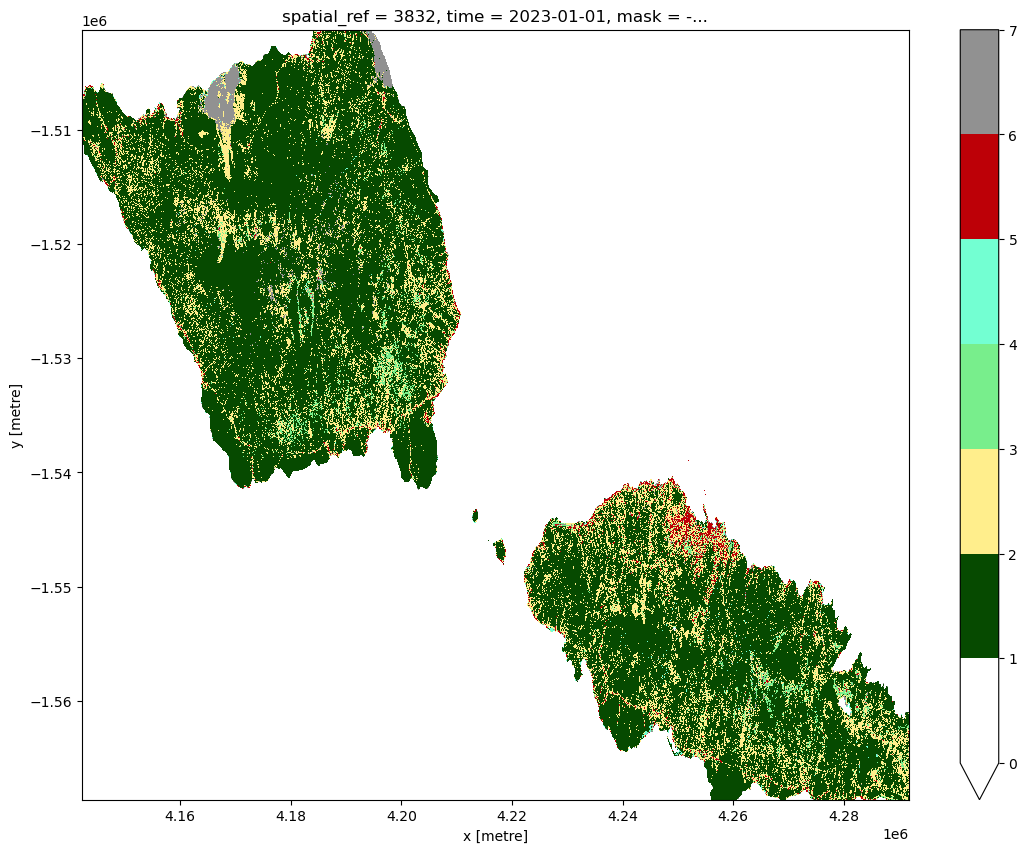

In [34]:
values_list = [c[0] for c in classes]
color_list = [c[2] for c in classes]

# Build a listed colormap.
c_map = colors.ListedColormap(color_list)
bounds = values_list + [7]
norm = colors.BoundaryNorm(bounds, c_map.N)

predicted_int.plot.imshow(cmap=c_map, norm=norm, size=10)

In [35]:
predicted_int.odc.write_cog(f"{version}-prediction-3.tiff", overwrite=True)

PosixPath('mw-samoa-02032026-prediction-3.tiff')

In [36]:
training

,lulc_class,value_id,lulc_code,geometry
0,Settlements,5,5,POINT (-171.80608 -13.82372)
1,Settlements,5,5,POINT (-171.8146 -13.82825)
2,Settlements,5,5,POINT (-171.81379 -13.82703)
3,Settlements,5,5,POINT (-171.8214 -13.82675)
4,Settlements,5,5,POINT (-171.80683 -13.8275)
...,...,...,...,...
393,Grassland,3,3,POINT (-172.10402 -13.84666)
394,Grassland,3,3,POINT (-172.10385 -13.84695)
395,Grassland,3,3,POINT (-172.10818 -13.84091)
396,Grassland,3,3,POINT (-172.10788 -13.8411)


In [44]:
print(training["lulc_class"].value_counts())

lulc_class
Settlements    92
Land           79
Forest         72
Grassland      55
Cropland       50
Wetlands       50
Name: count, dtype: int64


In [37]:
df = pd.read_csv("training-data/mw-samoa-27022026_postcard_4-training.csv")

In [38]:
df

,lulc_code,nir,red,blue,green,emad,smad,bcmad,nir08,nir09,...,swir22_swir16,mci,ndci,nbi,ndmi,bsi,awei,tc_wetness,y,x
0,5,0.5859,0.5971,0.5806,0.6032,0.087675,1.593828e-08,0.000002,0.6082,0.5093,...,0.914433,0.925008,0.029500,0.027794,-0.027794,-0.001288,0.422250,0.174120,-1543795.0,4251725.0
1,5,0.4178,0.4419,0.4672,0.4557,0.225469,1.460910e-07,0.000008,0.4066,0.3904,...,0.999786,1.184576,-0.112258,0.054965,-0.054965,0.012938,0.396725,0.036713,-1544315.0,4250775.0
2,5,0.3451,0.1273,0.1354,0.1021,0.068352,1.778841e-07,0.000003,0.3477,0.2732,...,2.758621,1.078437,0.430807,-0.344633,0.344633,0.103377,-0.263300,-0.090507,-1544175.0,4250865.0
3,5,0.2732,0.1185,0.1725,0.1348,0.082369,1.745343e-07,0.000005,0.2939,0.2795,...,1.145824,1.733503,0.141615,-0.126366,0.126366,-0.104585,-0.157450,-0.064524,-1544145.0,4250025.0
4,5,0.3521,0.3850,0.4085,0.4062,0.350881,9.259283e-08,0.000011,0.4286,0.3897,...,1.141896,0.720041,0.118993,0.267755,-0.267755,0.174024,0.155475,-0.097274,-1544225.0,4251645.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,3,0.3545,0.1075,0.0808,0.1235,0.119589,4.241317e-07,0.000006,0.3688,0.4119,...,0.681574,1.886642,0.272173,-0.118297,0.118297,-0.187236,-0.513825,-0.077104,-1546415.0,4218565.0
374,3,0.3705,0.0813,0.0629,0.1068,0.120873,4.034221e-07,0.000006,0.3992,0.2651,...,0.611048,2.025697,0.384557,-0.170616,0.170616,-0.283958,-0.579500,-0.072142,-1546445.0,4218585.0
375,3,0.4024,0.0946,0.0801,0.1271,0.120185,3.391653e-07,0.000006,0.4485,0.2922,...,0.572631,2.381065,0.282246,-0.191061,0.191061,-0.315431,-0.576575,-0.072995,-1545755.0,4218095.0
376,3,0.3983,0.0920,0.0768,0.1261,0.178438,4.424453e-07,0.000008,0.4442,0.3829,...,0.670225,1.786099,0.415873,-0.083073,0.083073,-0.198083,-0.654700,-0.107656,-1545775.0,4218135.0


In [39]:
len(df)

378

In [42]:
print(df["lulc_code"].value_counts())
# df = training['LULC_code'] != 8

lulc_code
5    92
1    72
6    64
3    54
2    50
4    46
Name: count, dtype: int64
